In [39]:
from shapely.geometry import Point
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import libpysal.weights
import esda
import spreg
import mgwr
import statsmodels.api as sm
from splot.esda import plot_moran, lisa_cluster

# Load data
df = pd.read_excel("C:/Uner/Lomba/Smatic/Dataset/Data Smatic.xlsx", sheet_name=0)
gdf = gpd.read_file("C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp")

# Standarisasi nama provinsi
df['Provinsi'] = df['Provinsi'].str.upper()
gdf['NAME_1'] = gdf['NAME_1'].str.upper()

# Gabungkan shapefile dan data
merged = gdf.merge(df, left_on='NAME_1', right_on='Provinsi')


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_5696\2515485953.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(merged)
c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
 There are 3 islands with ids: 1, 17, 18.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 17, ' is an island (no neighbors)')
('WARNING: ', 18, ' is an island (no neighbors)')


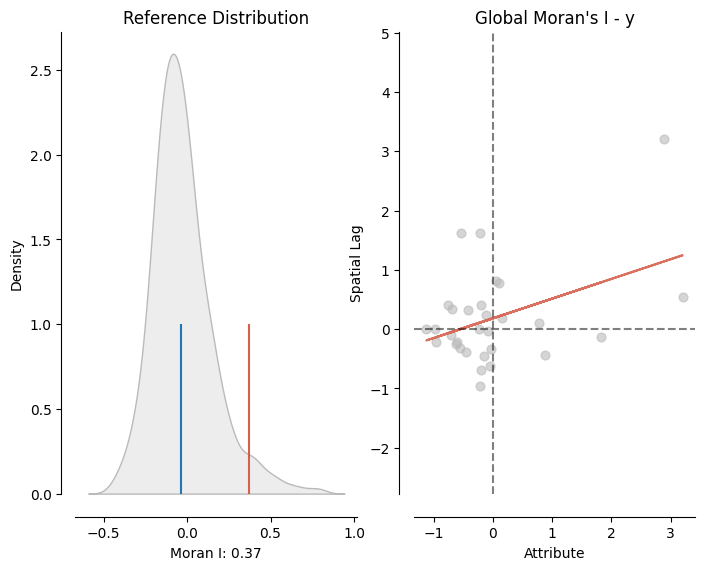

In [40]:
from esda.moran import Moran
from libpysal.weights import Queen
from splot.esda import plot_moran

# Spatial weights
w = Queen.from_dataframe(merged)
w.transform = 'r'

# Hitung Moran's I untuk variabel target (y)
moran = Moran(merged['y'], w)

# Plot
plot_moran(moran, zstandard=True, figsize=(8, 6))
plt.title("Global Moran's I - y")
plt.show()


c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\esda\moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


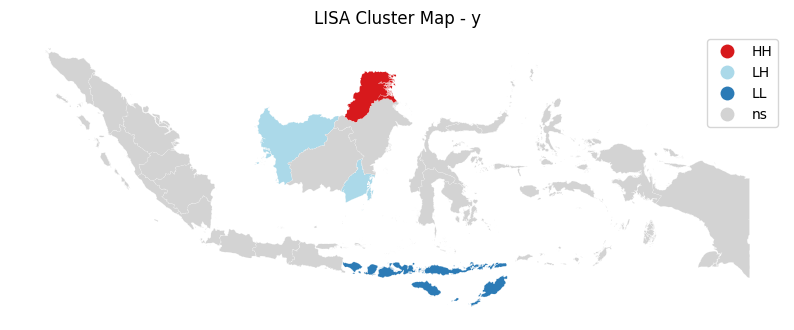

In [41]:
from esda.moran import Moran_Local
from splot.esda import lisa_cluster

# LISA
lisa = Moran_Local(merged['y'], w)

# Peta klaster LISA
fig, ax = plt.subplots(1, figsize=(10, 8))
lisa_cluster(lisa, merged, p=0.05, ax=ax)
plt.title("LISA Cluster Map - y")
plt.show()


In [42]:
from spreg import OLS, ML_Lag, ML_Error
import numpy as np

# Siapkan X dan y
y = merged['y'].values.reshape((-1, 1))
X = merged[['x1','x2','x3','x4','x5','x6','x7','x8']].values

# Tambah konstanta
X = np.hstack([np.ones_like(y), X])

# Model OLS
ols_model = OLS(y, X, w=w, name_y='y', name_x=['const','x1','x2','x3','x4','x5','x6','x7','x8'])
print(ols_model.summary)

# Model SAR
sar_model = ML_Lag(y, X, w=w)
print(sar_model.summary)

# Model SEM
sem_model = ML_Error(y, X, w=w)
print(sem_model.summary)



REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           y                Number of Observations:          30
Mean dependent var  :  73105.5000                Number of Variables   :           9
S.D. dependent var  :  45358.8638                Degrees of Freedom    :          21
R-squared           :      0.4044
Adjusted R-squared  :      0.1775
Sum squared residual: 3.55372e+10                F-statistic           :      1.7823
Sigma-square        :1692249027.609                Prob(F-statistic)     :      0.1377
S.E. of regression  :   41136.955                Log likelihood        :    -355.958
Sigma-square ML     :1184574319.326                Akaike info criterion :     729.916
S.E of regression ML:  34417.6455                Schwarz criterion     :     742.527

--------------------------------------------------------

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


In [43]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Hitung VIF
X_df = pd.DataFrame(X[:,1:], columns=['x1','x2','x3','x4','x5','x6','x7','x8'])
vif_data = pd.DataFrame()
vif_data['feature'] = X_df.columns
vif_data['VIF'] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
print(vif_data)

# Pilih fitur dengan VIF < 5 (misal)
selected = vif_data[vif_data['VIF'] < 10]['feature'].tolist()


  feature        VIF
0      x1  42.535170
1      x2  21.871468
2      x3  43.022732
3      x4   4.458252
4      x5   2.392534
5      x6  73.943967
6      x7   1.788065
7      x8   9.073174


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_sel = scaler.fit_transform(merged[selected])
X = np.hstack([np.ones((X_sel.shape[0], 1)), X_sel])  # tambah intercept


In [45]:
from spreg import OLS, ML_Lag, ML_Error
from libpysal.weights.contiguity import Queen
from libpysal.weights import lag_spatial

# Spatial weight matrix (gunakan shapefile)
w = w  # kamu sudah mendefinisikannya di awal

# Target
y = merged['y'].values.reshape((-1, 1))

# Nama variabel
names = ['const'] + selected

# --- Model OLS ---
ols_model = OLS(y, X, w=w, name_y='y', name_x=names, name_w='queen_w')
print(ols_model.summary)

# --- Model SAR (Lag) ---
sar_model = ML_Lag(y, X, w=w, name_y='y', name_x=names, name_w='queen_w')
print(sar_model.summary)

# --- Model SEM (Error) ---
sem_model = ML_Error(y, X, w=w, name_y='y', name_x=names, name_w='queen_w')
print(sem_model.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :     queen_w
Dependent Variable  :           y                Number of Observations:          30
Mean dependent var  :  73105.5000                Number of Variables   :           5
S.D. dependent var  :  45358.8638                Degrees of Freedom    :          25
R-squared           :      0.0719
Adjusted R-squared  :     -0.0766
Sum squared residual: 5.53747e+10                F-statistic           :      0.4843
Sigma-square        :2214987952.612                Prob(F-statistic)     :      0.7471
S.E. of regression  :   47063.659                Log likelihood        :    -362.611
Sigma-square ML     :1845823293.844                Akaike info criterion :     735.222
S.E of regression ML:  42963.0457                Schwarz criterion     :     742.228

--------------------------------------------------------

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


In [46]:
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from sklearn.preprocessing import StandardScaler
import numpy as np

# [1] Koordinat centroid dari masing-masing provinsi
u = merged.geometry.centroid.x
v = merged.geometry.centroid.y
coords = list(zip(u, v))

# [2] Siapkan variabel X dan y
X_raw = merged[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']].values
y = merged['y'].values.reshape(-1, 1)

# [3] Standardisasi prediktor (X)
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)

# [4] Gunakan kernel tetap untuk menghindari error
selector = Sel_BW(coords, y, X_std, fixed=True)
bw = selector.search()

# [5] Estimasi GWR dengan bandwidth terpilih
gwr_model = GWR(coords, y, X_std, bw, fixed=True).fit()

# [6] Tampilkan ringkasan hasil GWR
print(f"Bandwidth optimal (fixed): {bw}")
print(gwr_model.summary())


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_5696\3288360761.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  u = merged.geometry.centroid.x
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_5696\3288360761.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  v = merged.geometry.centroid.y


Bandwidth optimal (fixed): 85.43
Model type                                                         Gaussian
Number of observations:                                                  30
Number of covariates:                                                     9

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       35537229579.784
Log-likelihood:                                                    -355.958
AIC:                                                                729.916
AICc:                                                               743.495
BIC:                                                           35537229508.359
R2:                                                                   0.404
Adj. R2:                                                              0.177

Variable                              Est.         SE  t(Est/SE)    p-value
---------------------

In [47]:
from mgwr.gwr import GWR
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- [1] Koordinat titik centroid ---
u = merged.geometry.centroid.x
v = merged.geometry.centroid.y
coords = list(zip(u, v))

# --- [2] Feature selection (berdasarkan hasil VIF misalnya) ---
selected_features = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7','x8']
X_raw = merged[selected_features].values
y = merged['y'].values.reshape(-1, 1)

# --- [3] Standardisasi X ---
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)

from mgwr.sel_bw import Sel_BW
selector = Sel_BW(coords, y, X_std, fixed=True, constant=True)
bw = selector.search()
print(f"Bandwidth optimal: {bw}")

# --- [5] Estimasi GWR tanpa intercept manual ---
gwr_model = GWR(coords, y, X_std, bw, fixed=True, constant=True).fit()

# --- [6] Ringkasan hasil model ---
print(gwr_model.summary())

# --- [7] (Opsional) Simpan koefisien ke dalam dataframe ---
for i, col in enumerate(['Intercept'] + selected_features):
    merged[f'coef_{col}'] = gwr_model.params[:, i]


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_5696\1903368175.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  u = merged.geometry.centroid.x
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_5696\1903368175.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  v = merged.geometry.centroid.y


Bandwidth optimal: 85.43
Model type                                                         Gaussian
Number of observations:                                                  30
Number of covariates:                                                     9

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       35537229579.784
Log-likelihood:                                                    -355.958
AIC:                                                                729.916
AICc:                                                               743.495
BIC:                                                           35537229508.359
R2:                                                                   0.404
Adj. R2:                                                              0.177

Variable                              Est.         SE  t(Est/SE)    p-value
-----------------------------

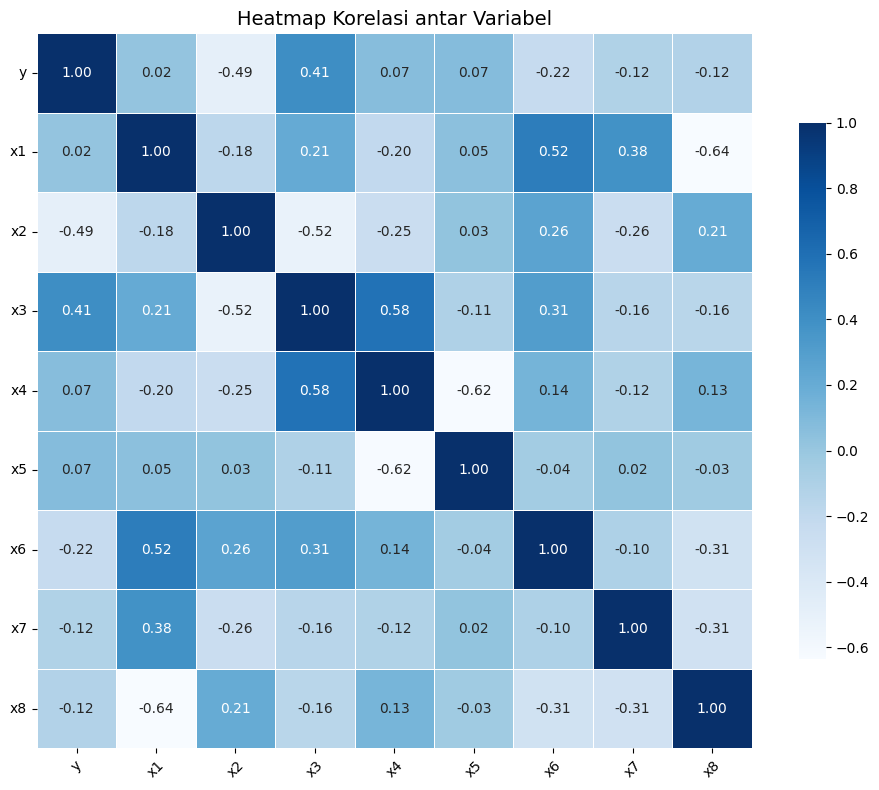

In [48]:
# --- 1. Gabungkan y dan X ke dalam satu DataFrame ---
subset_df = merged[['y', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']]

# --- 2. Hitung matriks korelasi ---
corr_matrix = subset_df.corr()

# --- 3. Plot heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75}
)
plt.title("Heatmap Korelasi antar Variabel", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

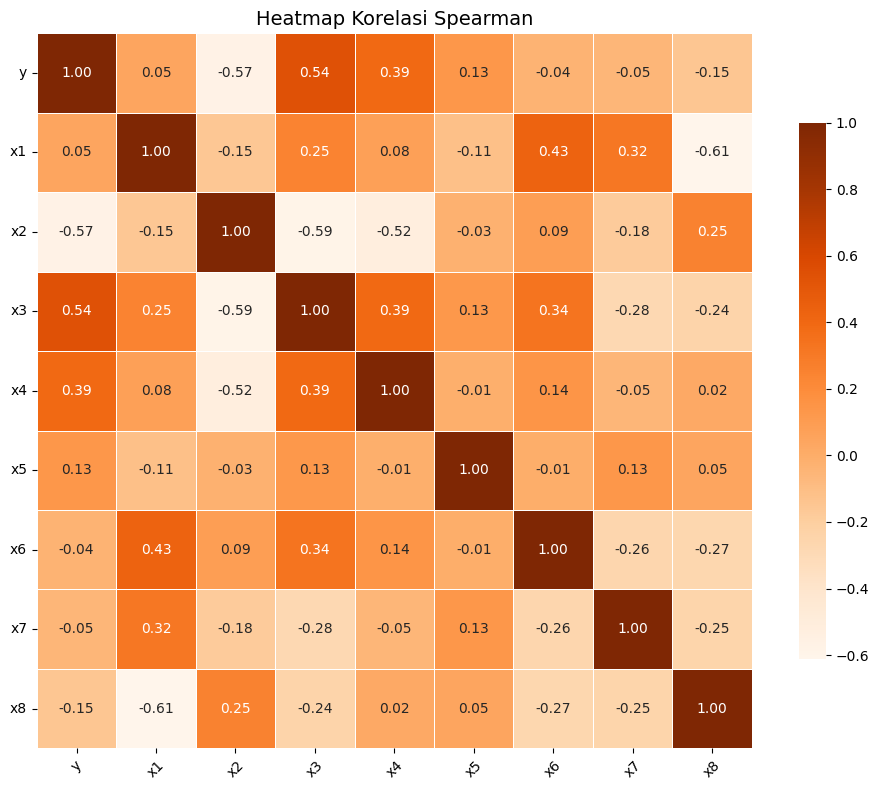

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Siapkan subset data ---
subset_df = merged[['y', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']]

# --- 2. Korelasi Spearman ---
spearman_corr = subset_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap='Oranges',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75}
)
plt.title("Heatmap Korelasi Spearman", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



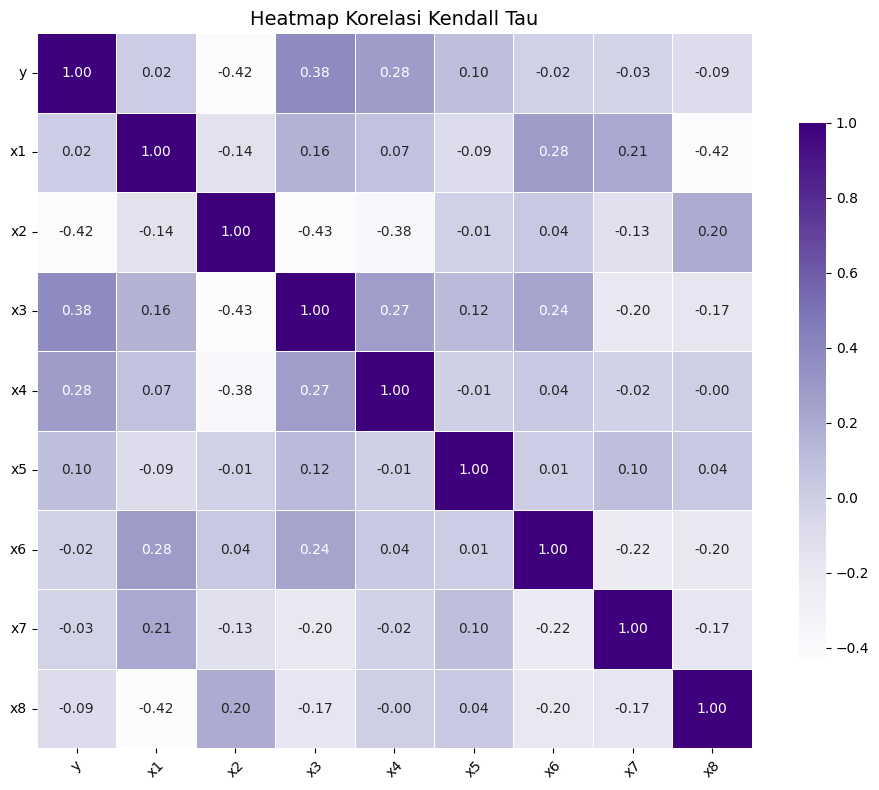

In [62]:
# --- 3. Korelasi Kendall ---
kendall_corr = subset_df.corr(method='kendall')

plt.figure(figsize=(10, 8))
sns.heatmap(
    kendall_corr,
    annot=True,
    fmt=".2f",
    cmap='Purples',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75}
)
plt.title("Heatmap Korelasi Kendall Tau", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [49]:
# Tambahkan koefisien GWR ke GeoDataFrame (skip intercept di index 0)
for i, col in enumerate(['x1','x2','x3','x4','x5','x6','x7','x8']):
    merged[f'GWR_{col}'] = gwr_model.params[:, i + 1]  # i+1 karena index 0 adalah intercept

# Tambahkan prediksi dan residual
merged['GWR_Pred'] = gwr_model.predy.flatten()
merged['GWR_Res'] = merged['y'] - merged['GWR_Pred']


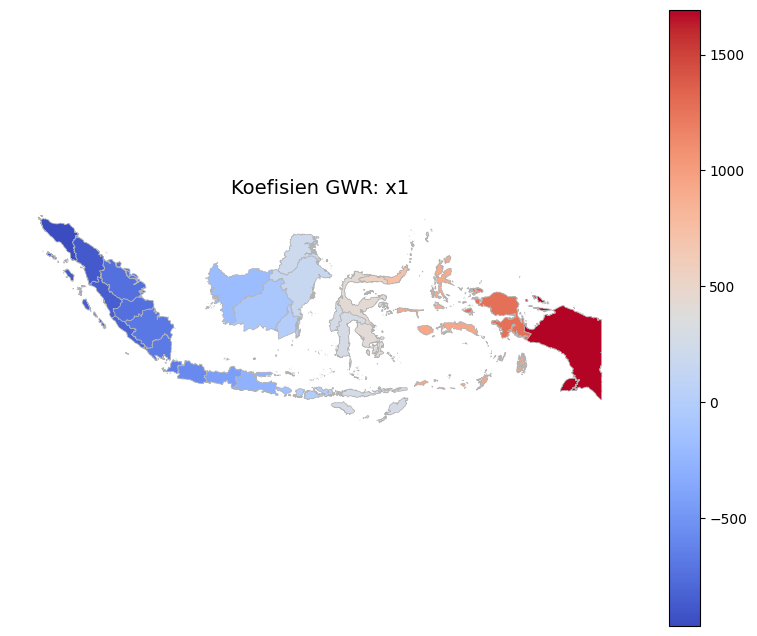

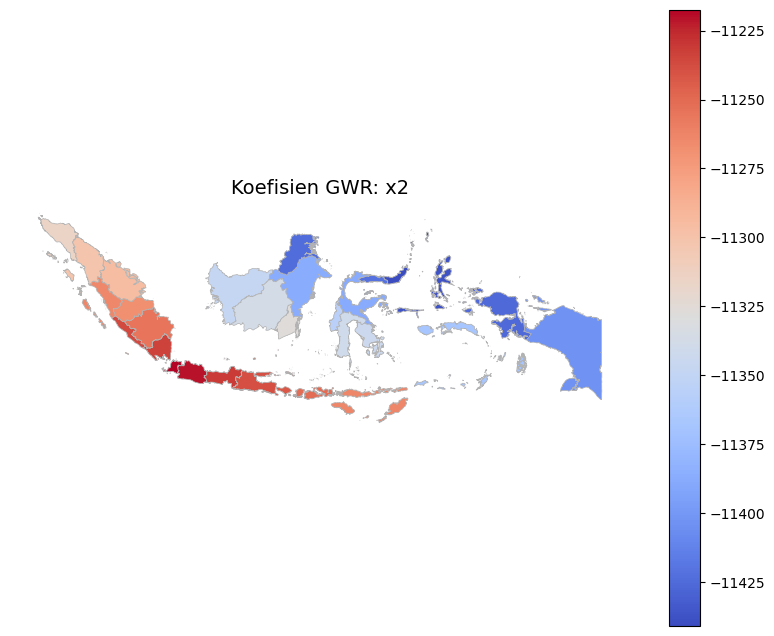

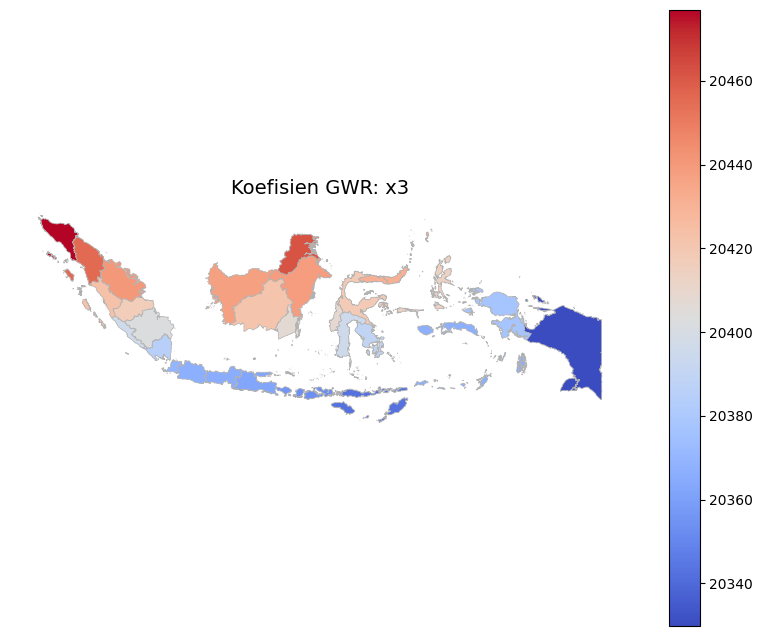

In [50]:
def plot_gwr_coef(geo_df, column, title):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    geo_df.plot(column=column, cmap='coolwarm', linewidth=0.5, edgecolor='0.7', legend=True, ax=ax)
    ax.set_title(f'Koefisien GWR: {title}', fontsize=14)
    ax.axis('off')
    plt.show()

# Contoh visualisasi 3 koefisien
plot_gwr_coef(merged, 'GWR_x1', 'x1')
plot_gwr_coef(merged, 'GWR_x2', 'x2')
plot_gwr_coef(merged, 'GWR_x3', 'x3')

# Lanjutkan untuk x4 sampai x8 sesuai kebutuhan


## Uji Asumsi

In [51]:
#Multikolinearitas
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF hanya bisa dihitung tanpa intercept
X_vif = merged[['x1','x4','x7','x8']]
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)


  Variable       VIF
0       x1  3.948775
1       x4  1.119763
2       x7  1.491404
3       x8  3.293531


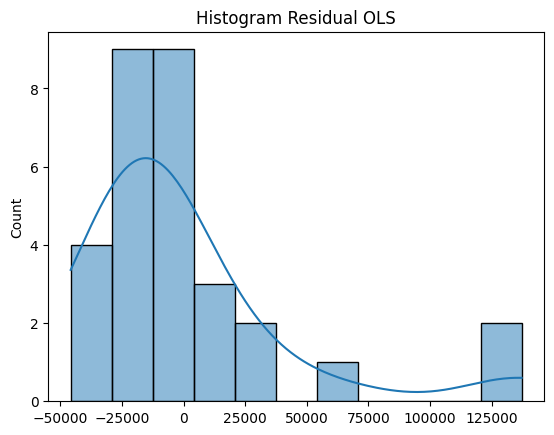

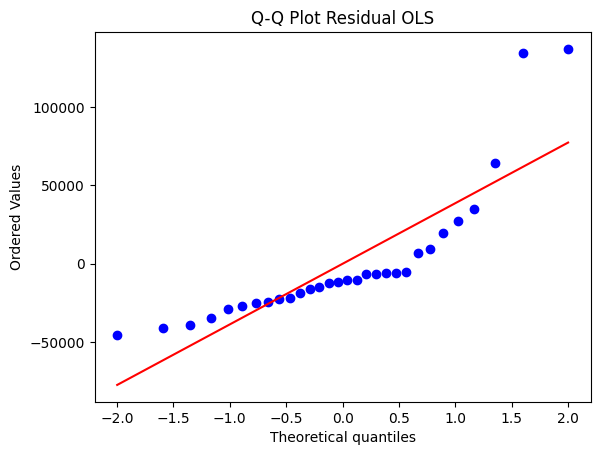

Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.7366916275655961), pvalue=np.float64(5.590249564448728e-06))


In [52]:
#Normalitas
import scipy.stats as stats
import matplotlib.pyplot as plt

residuals_ols = ols_model.u.flatten()

# Histogram + Q-Q plot
sns.histplot(residuals_ols, kde=True)
plt.title("Histogram Residual OLS")
plt.show()

stats.probplot(residuals_ols, dist="norm", plot=plt)
plt.title("Q-Q Plot Residual OLS")
plt.show()

# Shapiro-Wilk test
shapiro_test = stats.shapiro(residuals_ols)
print("Shapiro-Wilk:", shapiro_test)


In [53]:
#Heteroskedastisitas
from statsmodels.stats.diagnostic import het_breuschpagan

# Gunakan model statsmodels untuk BP Test
X_sm = sm.add_constant(X_vif)
ols_sm = sm.OLS(y, X_sm).fit()
bp_test = het_breuschpagan(ols_sm.resid, X_sm)
print(f"Breusch-Pagan p-value: {bp_test[1]}")


Breusch-Pagan p-value: 0.8311412786888698


In [54]:
#Uji Autokorelasi Spasial Residual
# Uji Global Moran's I pada residual
moran_resid_ols = Moran(residuals_ols, w)
print(f"Moran’s I Residual OLS: {moran_resid_ols.I}, p-value: {moran_resid_ols.p_sim}")

# Untuk SAR dan SEM
residuals_sar = sar_model.u
residuals_sem = sem_model.u

print(f"Moran’s I Residual SAR: {Moran(residuals_sar, w).I}, p-value: {Moran(residuals_sar, w).p_sim}")
print(f"Moran’s I Residual SEM: {Moran(residuals_sem, w).I}, p-value: {Moran(residuals_sem, w).p_sim}")


Moran’s I Residual OLS: 0.38943535528329404, p-value: 0.026
Moran’s I Residual SAR: 0.10427350728829592, p-value: 0.19
Moran’s I Residual SEM: 0.5352498386471684, p-value: 0.02


In [55]:
#Feature Selection
import statsmodels.api as sm
from itertools import combinations

X_names = ['x1','x2','x3','x4','x5','x6','x7','x8']
best_aic = np.inf
best_vars = None

for k in range(1, len(X_names)+1):
    for vars_combo in combinations(X_names, k):
        X_sel = sm.add_constant(merged[list(vars_combo)])
        model = sm.OLS(y, X_sel).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_vars = vars_combo

print(f"Best variable combination: {best_vars}, AIC: {best_aic}")

Best variable combination: ('x2', 'x7'), AIC: 722.6772607465964


In [56]:
selected_vars = ['x2', 'x7']
X_selected = merged[selected_vars].values
X_std_sel = scaler.fit_transform(X_selected)
X_sel = np.hstack([np.ones_like(y), X_selected])

# OLS ulang
ols_model_sel = OLS(y, X_sel, w=w, name_y='y', name_x=['const']+selected_vars)
print(ols_model_sel.summary)

# GWR ulang
selector_sel = Sel_BW(coords, y, X_std_sel, fixed=True)
bw_sel = selector_sel.search()
gwr_model_sel = GWR(coords, y, X_std_sel, bw_sel, fixed=True).fit()
print(gwr_model_sel.summary())


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           y                Number of Observations:          30
Mean dependent var  :  73105.5000                Number of Variables   :           3
S.D. dependent var  :  45358.8638                Degrees of Freedom    :          27
R-squared           :      0.3019
Adjusted R-squared  :      0.2502
Sum squared residual: 4.16498e+10                F-statistic           :      5.8394
Sigma-square        :1542585087.250                Prob(F-statistic)     :    0.007808
S.E. of regression  :   39275.757                Log likelihood        :    -358.339
Sigma-square ML     :1388326578.525                Akaike info criterion :     722.677
S.E of regression ML:  37260.2547                Schwarz criterion     :     726.881

--------------------------------------------------------

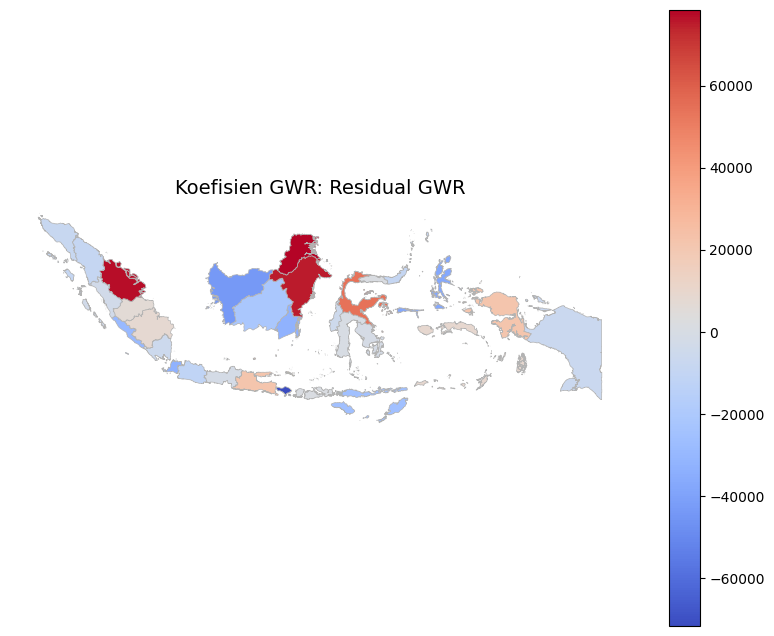

In [57]:
plot_gwr_coef(merged, 'GWR_Res', 'Residual GWR')


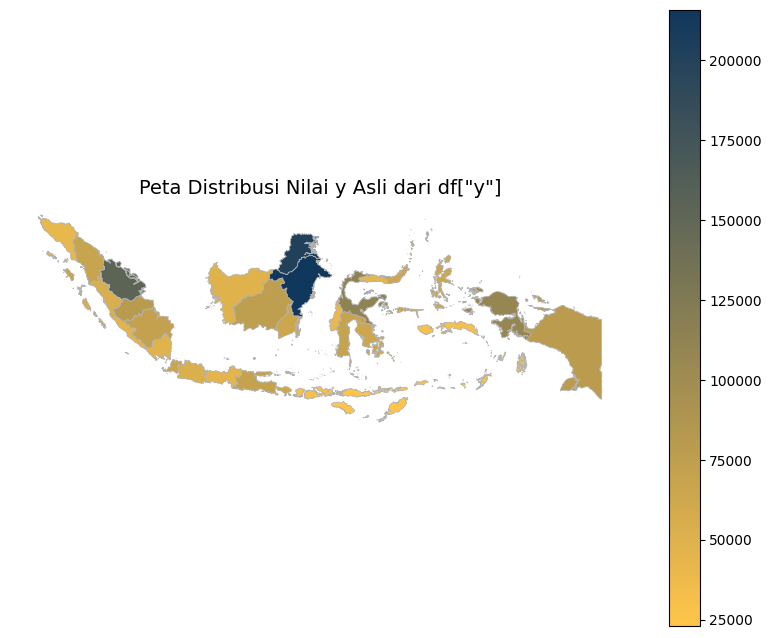

In [58]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

merged = merged.drop(columns=['y'], errors='ignore')  # hapus 'y' di merged jika sudah ada
merged = merged.merge(df[['Provinsi', 'y']], on='Provinsi', how='left')

# --- [3] Buat colormap kustom dari kuning ke biru gelap ---
colors = ['#FFC54A', '#10375C']
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# --- [4] Visualisasi distribusi nilai y ---
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
merged.plot(
    column='y',
    cmap=custom_cmap,
    linewidth=0.5,
    edgecolor='0.7',
    legend=True,
    ax=ax
)

ax.set_title('Peta Distribusi Nilai y Asli dari df["y"]', fontsize=14)
ax.axis('off')
plt.show()


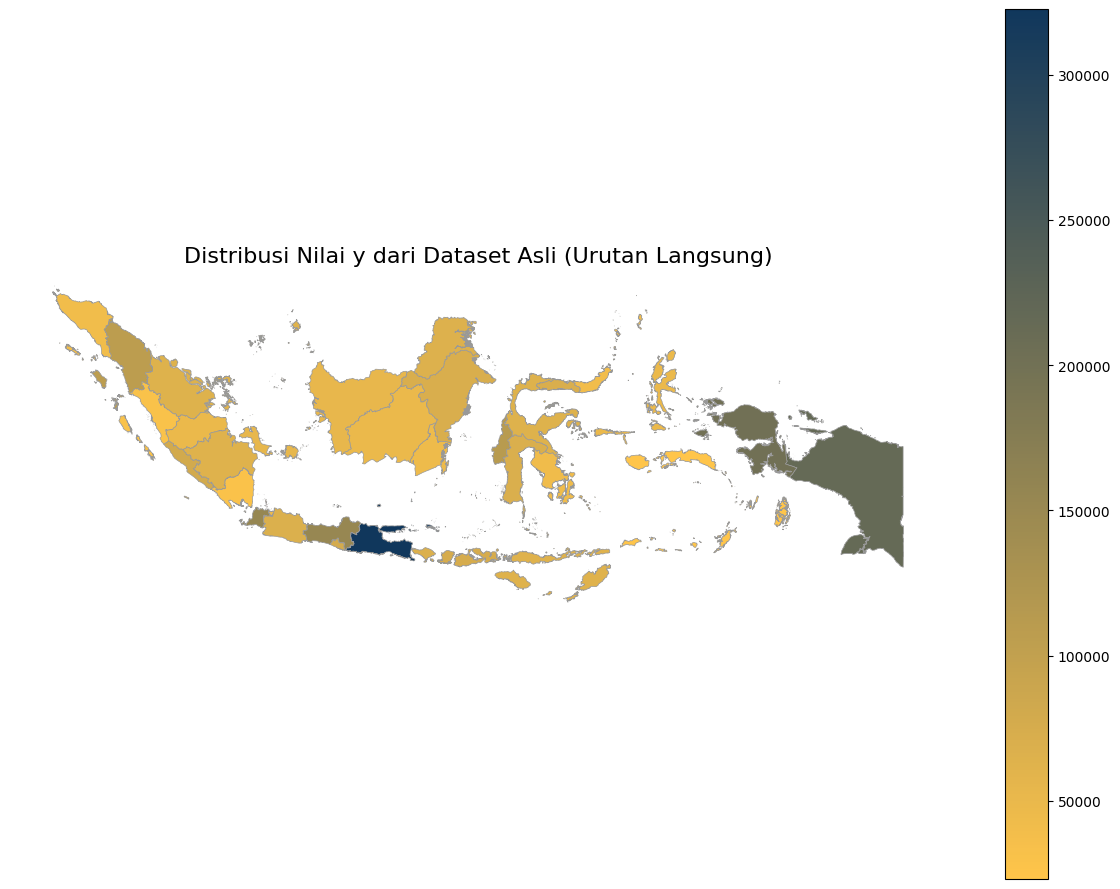

In [59]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- 2. Pastikan gdf dan df punya urutan provinsi yang cocok ---
# Misalnya kamu yakin urutan gdf sudah cocok dengan df, langsung assign:
gdf['y'] = df['y'].values  # INI PENTING — ambil langsung dari df

# --- 3. Buat colormap dari kuning ke biru gelap ---
colors = ['#FFC54A', '#10375C']
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# --- 4. Visualisasikan peta nilai y ---
fig, ax = plt.subplots(1, 1, figsize=(12, 9))
gdf.plot(
    column='y',
    cmap=custom_cmap,
    linewidth=0.5,
    edgecolor='0.6',
    legend=True,
    ax=ax
)

ax.set_title("Distribusi Nilai y dari Dataset Asli (Urutan Langsung)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

In [60]:
# Tampilkan 5 tertinggi
top5 = df[['Provinsi', 'y']].sort_values(by='y', ascending=False).head(5)

# Tampilkan 5 terendah
bottom5 = df[['Provinsi', 'y']].sort_values(by='y', ascending=True).head(5)

print("\n📈 Top 5 Provinsi dengan GDP per Kapita Tertinggi:")
print(top5.to_string(index=False))

print("\n📉 Top 5 Provinsi dengan GDP per Kapita Terendah:")
print(bottom5.to_string(index=False))



📈 Top 5 Provinsi dengan GDP per Kapita Tertinggi:
        Provinsi      y
     DKI JAKARTA 322619
KALIMANTAN TIMUR 215761
KALIMANTAN UTARA 201749
            RIAU 154522
       KEP. RIAU 154065

📉 Top 5 Provinsi dengan GDP per Kapita Terendah:
           Provinsi     y
NUSA TENGGARA TIMUR 23078
NUSA TENGGARA BARAT 29926
             MALUKU 30455
     SULAWESI BARAT 39547
               ACEH 41408
